#Tarea - Embeddings

In [ ]:
# Instalación e importación de librerias

import sys
import subprocess

try:
  import gensim
except ImportError:
  subprocess.check_call([sys.executable, "-m", "pip", "install", "gensim"])

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from gensim.models import Word2Vec
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:

# OBJETIVO DE LA TAREA:
# Repetir el flujo completo, pero con otro dominio.

# INSTRUCCIONES:
# 1. Usa este corpus y cámbialo por otro con al menos 20 comentarios sobre soporte técnico

corpus_alumnos = [
    "mi internet no funciona, necesito ayuda urgente",
    "la conexión se cae constantemente, es imposible trabajar",
    "olvidé mi contraseña y no puedo acceder a mi cuenta",
    "el sistema está muy lento desde la última actualización",
    "necesito configurar mi nuevo router, ¿pueden guiarme?",
    "mi computadora no enciende, qué puedo hacer?",
    "el software no se instala correctamente, me da un error",
    "tengo problemas con el wifi, la señal es muy débil",
    "mi impresora no imprime, ya revisé los cartuchos",
    "el equipo hace un ruido extraño, me preocupa que se dañe",
    "no puedo enviar correos electrónicos, me da un error de servidor",
    "la pantalla se congela y tengo que reiniciar el ordenador",
    "necesito asistencia para recuperar archivos borrados accidentalmente",
    "mi móvil no se conecta a la red celular",
    "tengo un virus en mi laptop, pueden eliminarlo?",
    "el audio no funciona en mi dispositivo",
    "la cámara web no es detectada por el sistema",
    "quiero cambiar la dirección IP de mi red local",
    "cómo puedo hacer una copia de seguridad de mis datos?",
    "el teclado dejó de funcionar de repente",
    "el disco duro está casi lleno, necesito liberar espacio",
    "mi cuenta ha sido hackeada, necesito ayuda para protegerla"
]

# ESCRIBE TU CÓDIGO AQUÍ ABAJO

print("Número de textos:", len(corpus_alumnos))
print("Primer ejemplo:")
print(corpus_alumnos[0])

Número de textos: 22
Primer ejemplo:
mi internet no funciona, necesito ayuda urgente


In [ ]:
# 2. Tokeniza el nuevo corpus

def limpiar_texto_simple(texto):

  texto = texto.lower()

  texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

  texto = re.sub(r"\s+", " ", texto).strip()

  tokens = texto.split()

  return tokens

corpus_tokeninzado = [limpiar_texto_simple(texto) for texto in corpus_alumnos]

print (" Corpus tokenizado:")
for fila in corpus_tokeninzado[:3]:
  print(fila)

 Corpus tokenizado:
['mi', 'internet', 'no', 'funciona', 'necesito', 'ayuda', 'urgente']
['la', 'conexión', 'se', 'cae', 'constantemente', 'es', 'imposible', 'trabajar']
['olvidé', 'mi', 'contraseña', 'y', 'no', 'puedo', 'acceder', 'a', 'mi', 'cuenta']


In [ ]:
# 3. Entrena un Word2Vec tu decide cual arquitectura usar

# Entrenamiento de Word2Vec con Skip-gram

modelo_w2v= Word2Vec(sentences= corpus_tokeninzado, vector_size=20, window=2, min_count=1, sg=1, epochs=200)

In [ ]:
# 4. Busca palabras similares a una palabra clave
# Vocabulario del modelo

vocabulario_w2v = list(modelo_w2v.wv.index_to_key)

print("Vocabulario aprendido:")
print(vocabulario_w2v)
print("Número de palara en el vocabulario: ", len(vocabulario_w2v))


Vocabulario aprendido:
['mi', 'el', 'no', 'la', 'de', 'se', 'necesito', 'un', 'puedo', 'tengo', 'me', 'es', 'en', 'red', 'para', 'que', 'error', 'da', 'hacer', 'pueden', 'muy', 'está', 'sistema', 'cuenta', 'a', 'y', 'ayuda', 'funciona', 'protegerla', 'hackeada', 'sido', 'ha', 'espacio', 'liberar', 'lleno', 'casi', 'duro', 'disco', 'repente', 'funcionar', 'dejó', 'teclado', 'datos', 'mis', 'seguridad', 'copia', 'una', 'cómo', 'local', 'ip', 'dirección', 'cambiar', 'quiero', 'por', 'detectada', 'web', 'cámara', 'dispositivo', 'audio', 'eliminarlo', 'laptop', 'virus', 'celular', 'conecta', 'móvil', 'accidentalmente', 'borrados', 'archivos', 'recuperar', 'asistencia', 'ordenador', 'reiniciar', 'congela', 'pantalla', 'servidor', 'electrónicos', 'correos', 'enviar', 'dañe', 'preocupa', 'extraño', 'ruido', 'hace', 'equipo', 'cartuchos', 'los', 'revisé', 'ya', 'imprime', 'impresora', 'débil', 'señal', 'wifi', 'con', 'problemas', 'correctamente', 'instala', 'software', 'qué', 'enciende', 'compu

In [ ]:
palabra_prueba= "necesito"

print(f"Similares a '{palabra_prueba}' con Skip-gram:")
print(modelo_w2v.wv.most_similar(palabra_prueba, topn=5))

Similares a 'necesito' con Skip-gram:
[('ayuda', 0.9886742234230042), ('asistencia', 0.987445592880249), ('protegerla', 0.9873563647270203), ('archivos', 0.9869569540023804), ('sido', 0.9861282110214233)]


In [ ]:
# Vector de una palabra

vector_necesito = modelo_w2v.wv[palabra_prueba]

print(f"Vector de '{palabra_prueba}':")
print(vector_necesito)

print("Dimenesión del vector:", len(vector_necesito))

Vector de 'necesito':
[-0.11789657 -0.13524628  0.5955635   0.26601502 -0.16330929  0.11383497
 -0.0617171   0.40830106 -0.22450602 -0.02912426  0.4642377  -0.23809075
  0.01559323 -0.10306488  0.4400481   0.35751465  0.6999388   0.15589792
 -0.09641802 -0.2929494 ]
Dimenesión del vector: 20


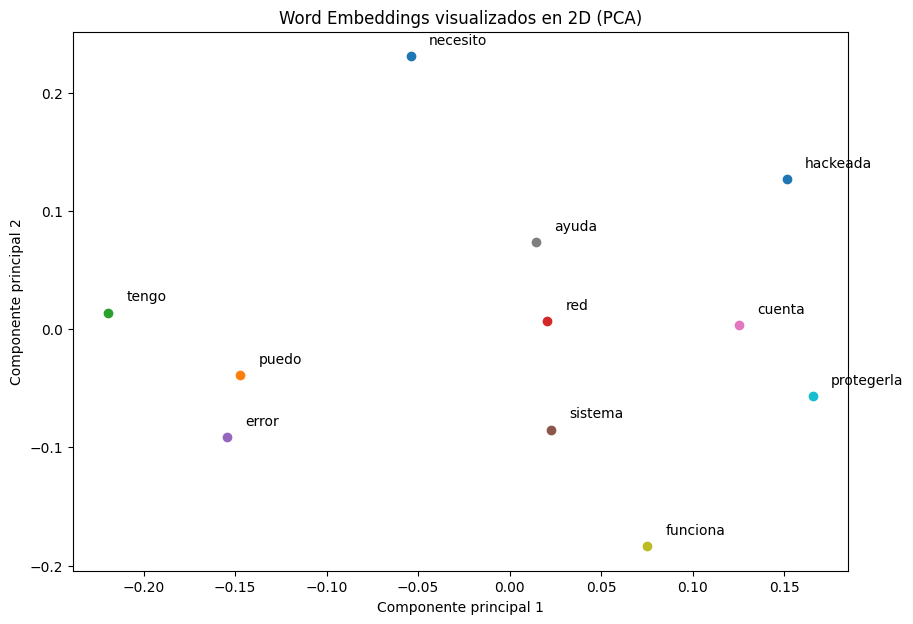

In [ ]:
#  Visualización 2D PCA

palabras_interes= [
    "necesito", "puedo", "tengo", "red", "error", "sistema",
    "cuenta", "ayuda", "funciona", "protegerla", "hackeada"
]
# Nos quedamos solo con palabras que realmente estén en el vocabulario
palabras_interes = [p for p in palabras_interes if p in modelo_w2v.wv]
# Extraer ñps vectpres de esas palabras
vectores =np.array([modelo_w2v.wv[p] for p in palabras_interes])
# Creamos el objeto PCA para reducir a 2 dimensiones
pca= PCA(n_components=2)
# fit_transform aprende la proyección y la aplica a los vectores
coords = pca.fit_transform(vectores)

# Grafica de las palabras
plt.figure(figsize=(10,7))

for i, palabra in enumerate(palabras_interes):
  x,y =coords[i]

  plt.scatter(x,y)

  plt.text(x+0.01, y+0.01, palabra, fontsize=10)

plt.title("Word Embeddings visualizados en 2D (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

In [ ]:
# 5. Construye la matriz de coocurrencia

vocabulario = sorted(set(token for frase in corpus_tokeninzado for token in frase))

indice = {palabra: i for i, palabra in  enumerate(vocabulario)}

matriz_cooc= np.zeros((len(vocabulario), len(vocabulario)), dtype=np.float32)

window_size=2
# Recorremos cada frase  del corpus
for frase in corpus_tokeninzado:
  # Recorrer palabra por palabra dentro de la frase
  for i, palabra in enumerate(frase):
    idx_palabra = indice[palabra]
    # Calculamos los limites izquierdo y derecho de la ventana
    inicio = max(0, i - window_size)
    fin = min(len(frase),i + window_size + 1)

    #Recorremos el contexto alrededor de la palabra central
    for j in range(inicio,fin):
      if i!=j:
        contexto = frase[j]
        idx_contexto = indice[contexto]

        #Sumamos 1 en la celda correspondiente
        #Esto significa que la palabra y el contexto
        #Aparecieron cerca una de otra
        matriz_cooc[idx_palabra, idx_contexto] +=1

print("Tamaño de la matriz de coocurrencia:", matriz_cooc.shape)
# Filtramos por si alguna palabra no existe
palabras_interes=[p for p in palabras_interes if p in indice]

indices_demodos = [indice[p] for p in palabras_interes]

submatriz = matriz_cooc[np.ix_(indices_demodos, indices_demodos)]

df_submatriz = pd.DataFrame(submatriz, index= palabras_interes, columns=palabras_interes)
print (df_submatriz)
print(" Tamaño de la submatriz de coocurrencia:", submatriz.shape)

Tamaño de la matriz de coocurrencia: (119, 119)
            necesito  puedo  tengo  red  error  sistema  cuenta  ayuda  \
necesito         0.0    0.0    0.0  0.0    0.0      0.0     0.0    2.0   
puedo            0.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
tengo            0.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
red              0.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
error            0.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
sistema          0.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
cuenta           0.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
ayuda            2.0    0.0    0.0  0.0    0.0      0.0     0.0    0.0   
funciona         1.0    0.0    0.0  0.0    0.0      0.0     0.0    1.0   
protegerla       0.0    0.0    0.0  0.0    0.0      0.0     0.0    1.0   
hackeada         1.0    0.0    0.0  0.0    0.0      0.0     0.0    1.0   

            funciona  protegerla  hackeada  
necesito         1

In [ ]:
# 6. Genera embeddings globales con SVD

svd = TruncatedSVD(n_components=10, random_state=42)

embeddings_globales= svd.fit_transform(matriz_cooc)

print("Embeddings globales generados")
print("Forma:", embeddings_globales.shape)

Embeddings globales generados
Forma: (119, 10)


In [ ]:
# Ejemplo de embeddings globales

if palabra_prueba in indice:
  print(f"Embedding global de '{palabra_prueba} (primeros 5 valores):")
  print(embeddings_globales[indice[palabra_prueba]][:5])

Embedding global de 'necesito (primeros 5 valores):
[ 1.5414901  -0.5177007   0.10732277 -1.2405102   0.4359412 ]


In [ ]:
# Similitud en embeddings globales

def palabras_similares_globales(palabra, topn=5):

  if palabra not in indice:
    return f"La palabra '{palabra}' no  está en el vocabulario."

  idx_palabra= indice[palabra]

  vector = embeddings_globales[idx_palabra].reshape(1,-1)

  # Comparamos ese vector con todos los vectores del vocabulario
  similitudes = cosine_similarity(vector, embeddings_globales)[0]

  top_idx= np.argsort(similitudes)[::-1]

  resultados =[]

  for j in top_idx:
    if vocabulario [j] != palabra:
      resultados.append((vocabulario[j], float(similitudes[j])))
    if len(resultados) == topn:
      break
  return resultados

print("Similares a 'ayuda' con embeddings globales:")
for word, score in palabras_similares_globales("ayuda"):
    print(f"- {word}: {score:.4f}")

print("\nSimilares a 'sistema' con embeddings globales:")
for word, score in palabras_similares_globales("sistema"):
    print(f"- {word}: {score:.4f}")

Similares a 'ayuda' con embeddings globales:
- urgente: 0.9959
- liberar: 0.9931
- asistencia: 0.9911
- para: 0.9879
- hackeada: 0.9806

Similares a 'sistema' con embeddings globales:
- disco: 0.9895
- ordenador: 0.9843
- por: 0.9840
- duro: 0.9787
- con: 0.9772


In [ ]:
# 7. Compara resultados entre:
#    - Word2Vec
#    - enfoque global tipo GloVe
palabra_objetivo = "necesito"

print(f"Word2Vec (Skip-gram) - similares a '{palabra_objetivo}':")
for word, score in modelo_w2v.wv.most_similar(palabra_objetivo, topn=5):
    print(f"- {word}: {score:.4f}")

print(f"\nCoocurrencia global tipo GloVe - similares a '{palabra_objetivo}':")
for word, score in palabras_similares_globales(palabra_objetivo, topn=5):
    print(f"- {word}: {score:.4f}")

Word2Vec (Skip-gram) - similares a 'necesito':
- ayuda: 0.9887
- asistencia: 0.9874
- protegerla: 0.9874
- archivos: 0.9870
- sido: 0.9861

Coocurrencia global tipo GloVe - similares a 'necesito':
- protegerla: 0.9288
- recuperar: 0.8807
- archivos: 0.8539
- hackeada: 0.6842
- ha: 0.6291


In [ ]:
# 8. Responde:
#    a) ¿Qué palabras quedaron cerca en Word2Vec?
#       similares a "necesito" quedaron: ayuda, asistencia y protegerla

#    b) ¿Qué palabras quedaron cerca en el enfoque global?
#       similares a "necesito" quedaron: protegerla, recuperar y archivos

#    c) ¿Coinciden siempre? ¿Por qué?
#       No coinciden siempre. Word2Vec es un modelo predictivo que captura
#       relaciones semánticas locales, mientras que el enfoque global (SVD)
#       se basa en estadísticas de conteo de coocurrencia en todo el corpus.

#    d) ¿Cuál te parece más interpretable?
#       Personalmente, Word2Vec porque captura mejor la semántica y
#       relaciones complejas a pesar de ser menos directo.